# Домашняя работа №2: Классификация при помощи CNN

В этом домашнем задании мы попрактикуемся в построении простого пайплайна обучения и имплементируем с нуля модель MobileNetV3. В качестве датасета возьмём Tiny ImageNet — это датасет, состоящий из 100 000 семплов размера 64х64 и относящихся к одному из 200 классов. Он является подвыборкой из оригинального ImageNet1K с уменьшенными картинками и меньшим количеством классов.

### План:
1. Работа с датасетом: посмотрим на сам датасет, проведём простой анализ данных, имплементируем необходимые классы для загрузки данных и работы с датасетом.
2. Имплементация MobileNetV3: реализуем два основных слоя: SqueezeExcitation и MBConv2d, затем вам будет предложено придумать свою собственную вариацию MobileNetV3, используя имплементированный MBConv2d в качестве строительного блока.
3. Построение пайплайна обучения и тренировка: вы построите простой пайплайн обучения и обучите вашу вариацию MobileNetV3 на Tiny ImageNet. Результат загрузите в LMS для тестирования на приватном датасете.

Импортируем все необходимые нам библиотеки.

In [1]:
!pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.1 MB/s eta 0:00:0000:010:01


In [2]:
import io
from typing import Union, Callable, Optional

import torch
import torch.nn as nn
import torchvision as tv
import torchvision.transforms.v2 as transforms
import pandas as pd
import numpy as np
import numpy.typing as npt
import PIL.Image as Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

## Часть 1. Работа с датасетом

В этом задании будем работать с датасетом Tiny ImageNet. Его можно скачать с HuggingFace: https://huggingface.co/datasets/zh-plus/tiny-imagenet/tree/main/data. Использовать будем только train-часть. Перед тем как приступать к обучению моделей, полезно провести хотя бы минимальный анализ датасета: количество данных, количество и сбалансированность классов, размеры картинок и одинаковы ли они во всём датасете. В данном случае с этой информацией можно ознакомиться в карточке датасета, однако чуть позже мы покажем, что некоторую важную информацию всё же понадобится получить самостоятельно.

Для начала прочитаем данные и посмотрим, из чего они состоят. Они хранятся в формате .parquet, и для чтения воспользуемся функцией `read_parquet` из `pandas` с 'fastparquet'-бэкендом.

In [3]:
data_path = "/kaggle/input/datasets/andreykurdyubov/tiny-imagenet/tiny_imagenet/train-00000-of-00001-1359597a978bc4fa.parquet" # замените на путь до .parquet-файла с train-частью датасета
df = pd.read_parquet(data_path, engine='fastparquet')
df.head()

,label,image.bytes,image.path
0,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,None
1,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,None
2,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,None
3,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,None
4,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,None


Видим, что датасет состоит из трёх колонок: label (класс картинки), image.bytes (картинка в виде байт-массива), image.path. Последняя колонка нам не нужна, поэтому можем дропнуть её. Затем загрузим все картинки и посмотрим на одну из них, чтобы проверить правильность загрузки.

In [4]:
df.drop(columns=['image.path'], inplace=True)
df.head()

,label,image.bytes
0,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
1,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
2,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
3,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
4,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...


Реализуйте функцию для чтения картинки по строке из DataFrame, содержащего данные из Tiny ImageNet. В столбце image.bytes датафрейма хранятся последовательности байтов, для работы с ними воспользуйтесь функциями из библиотеки io. Для получения картинки используйте библиотеку pillow.

Готовую функцию загрузите в LMS для автоматической проверки.

In [5]:
next(df.iterrows())[1].values[1]

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x00@\x00@\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4\xd

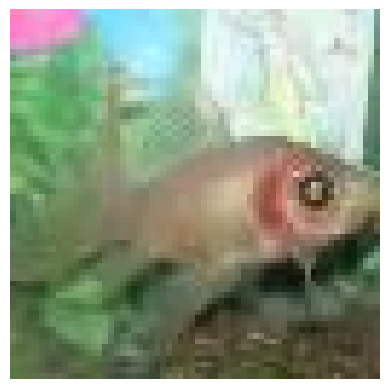

100000


In [6]:
def read_image(row: pd.Series) -> Image.Image:
    image = Image.open(io.BytesIO(row.values[1]))
    return image

all_images = [read_image(row) for i, row in df.iterrows()]

assert len(all_images) == len(df), "Не все картинки были считаны"

plt.imshow(all_images[0])
plt.axis('off')
plt.show()
print(len(df))

Отлично! Теперь проверим размеры и форматы картинок, одинаковы ли они между собой.

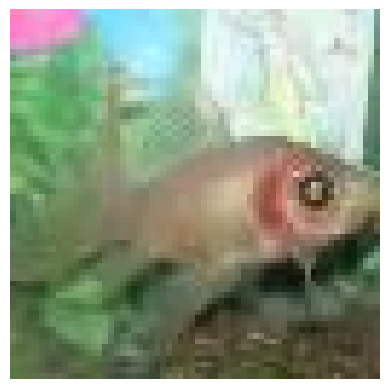

In [7]:
# решение автора
def read_image(row: pd.Series) -> Image.Image:
    image = Image.open(io.BytesIO(row['image.bytes']))
    return image

all_images = [read_image(row) for i, row in df.iterrows()]

assert len(all_images) == len(df), "Не все картинки были считаны"

plt.imshow(all_images[0])
plt.axis('off')
plt.show()

In [8]:
print("Общее число картинок:", len(all_images))

print("Количество картинок одинакового размера:", sum([1 for x in all_images if x.size == (64, 64)])) # Посчитайте количество картинок с пространственным размером, равным 64х64, эту информацию можно получить через аттрибут size
print("Количество картинок в RGB:", sum([1 for x in all_images if x.mode == "RGB"])) # Посчитайте число картинок в цветовом пространстве RGB, для этого используйте mode
print("Цветовые пространства картинок в датасете:", np.unique([x.mode for x in all_images])) # Примените np.unique к списку mode всех картинок, для того чтобы найти все цветовые пространства, встречающиеся в датасете
print("Количество картинок в GrayScale:", sum([1 for x in all_images if x.mode == "L"])) # Посчитайте число картинок в цветовом пространстве RGB, для этого используйте mode


Общее число картинок: 100000
Количество картинок одинакового размера: 100000
Количество картинок в RGB: 98179
Цветовые пространства картинок в датасете: ['L' 'RGB']
Количество картинок в GrayScale: 1821


Как видим, все картинки, действительно, равны по размеру, но при этом часть из них не в RGB, а в Grayscale, т.е. у картинок отличаются цветовые пространства, и это критично для обучения сети, поскольку может отличаться число каналов, а также информация внутри них. В данном случае таких картинок не особо много, поэтому можно будет конвертировать их в RGB и работать с ними, как с остальными RGB-картинками. В LMS отправьте количество Grayscale-картинок.

Давайте теперь имплементируем класс датасета, который будем в дальнейшем использовать для обучения нашей модели. Метод __getitem__ должен получить строку датафрейма с индексом idx и выдать лежащую там пару (картинка, лейбл). Не забудьте применить self.transform к картинке, dtype для лейбла должен быть torch.long.

Имплементацию отправьте в LMS для проверки.

In [9]:
torch.tensor(df.loc[0, "label"], dtype=torch.long)

tensor(0)

In [10]:
df.loc[0, "label"]

np.int64(0)

In [11]:
class TinyImageNetDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: Callable):
        super().__init__()

        self._data = df
        self.transform = transform

    def __len__(self) -> int:
        return len(self._data)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        sample = self._data.loc[idx, "image.bytes"] # Возьмите нужную строку из датафрейма по индексу
        lab = self._data.loc[idx, "label"]

        image = Image.open(io.BytesIO(sample)) # Считайте картинку, проверьте, подана ли она в RGB-формате, если нет, то конвертируйте в него. В конце примените self.transform к картинке
        if image.mode == "L":
            image = image.convert("RGB")            

        image = self.transform(image)
        label = torch.tensor(lab, dtype=torch.long) # Оберните label в тензор с torch.long-типом данных
        return image, label

tensor(0)


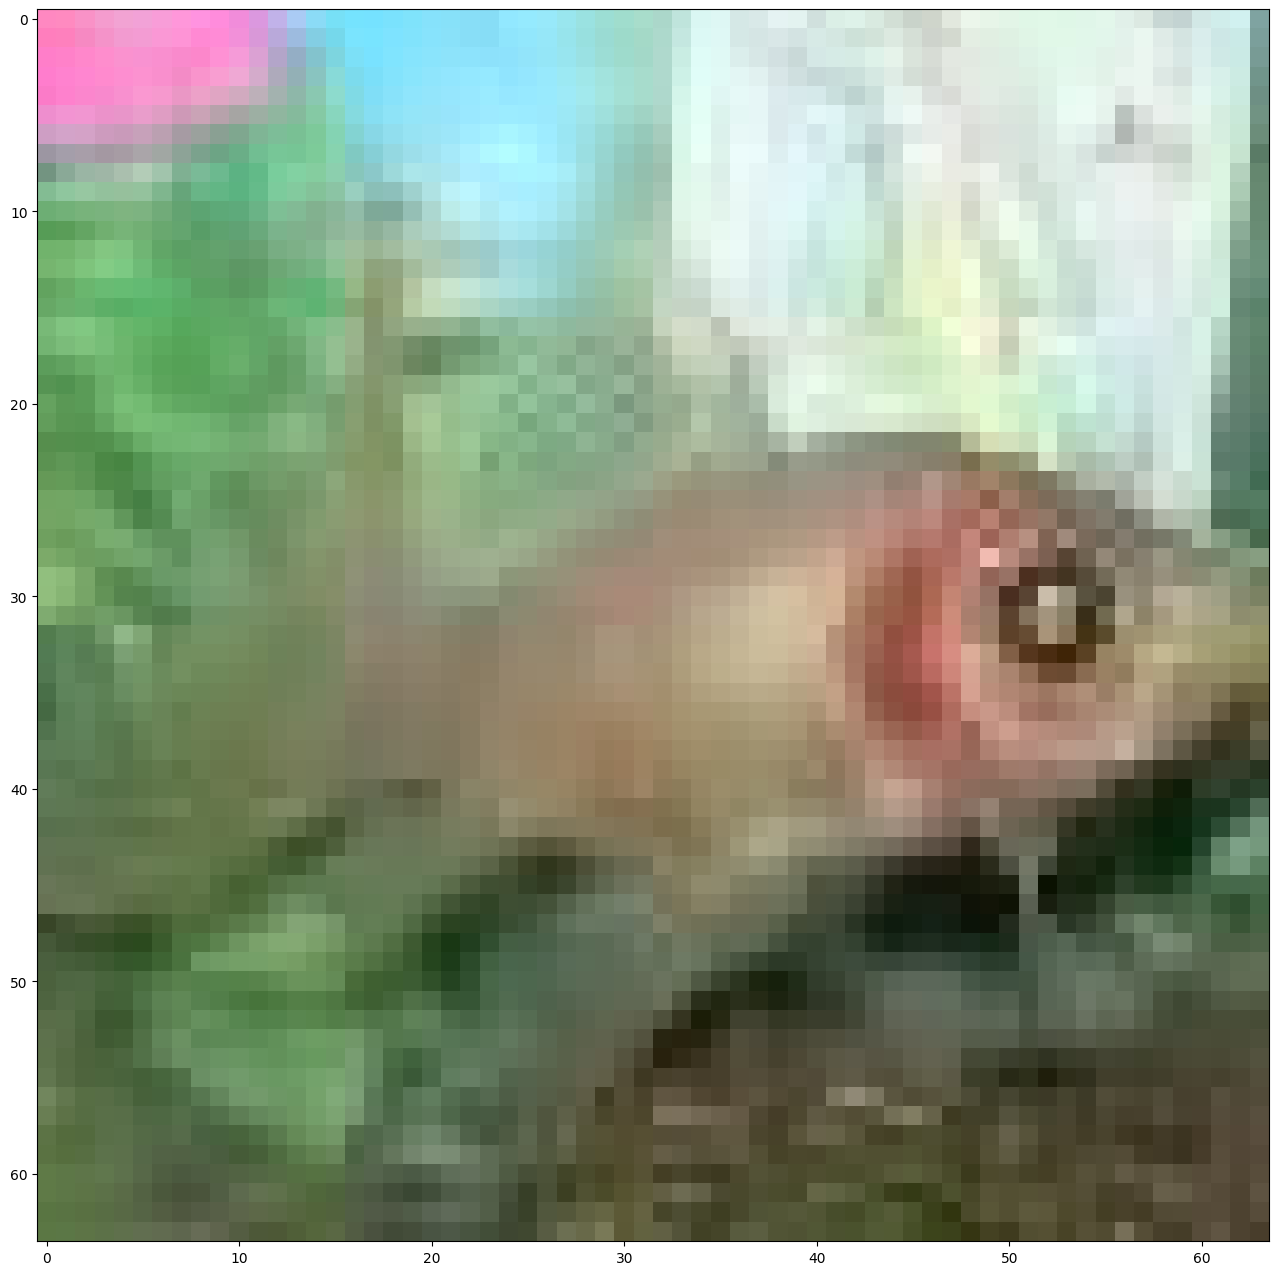

In [12]:
def myshow(img):
    img = img * 0.3 + 0.3 # умножаем на std, прибавляем mean - в Normalize всё наоборот
    npimg = img.detach().numpy()
    fig = plt.figure(figsize=(16, 16))
    plt.imshow(npimg.transpose(1, 2, 0))

transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3])
])

traindataset = TinyImageNetDataset(df, transform)
image, label = traindataset[0]
myshow(image)
print(label)

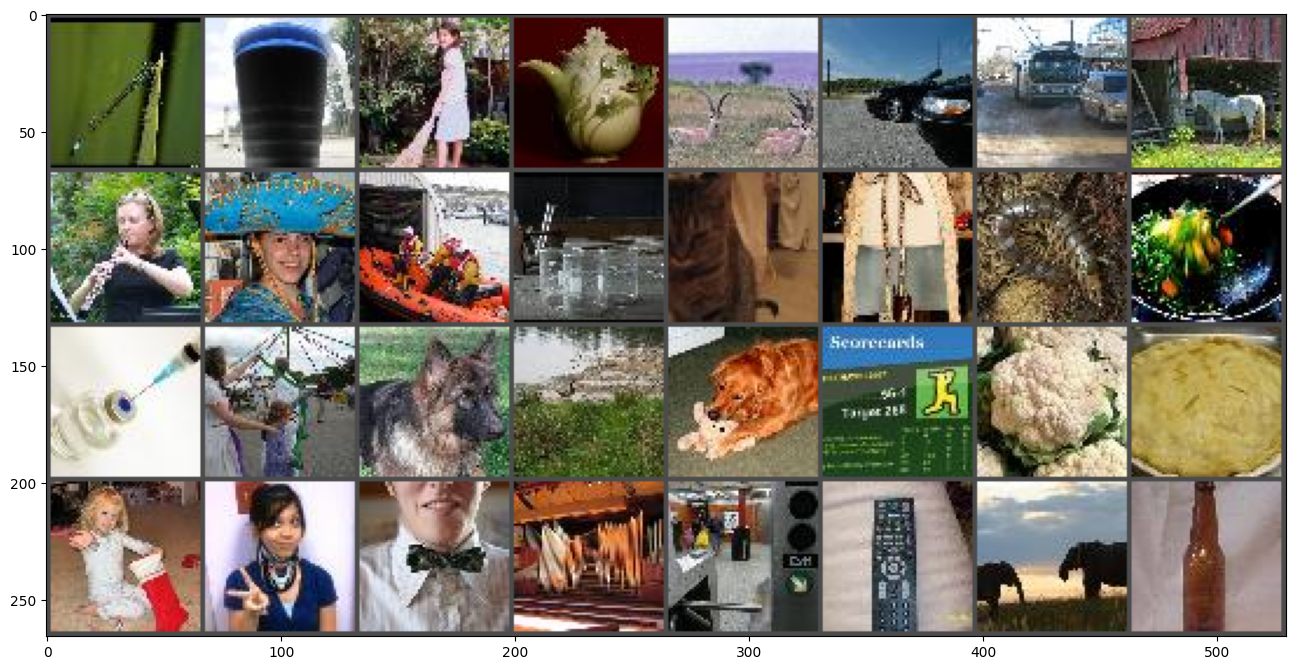

In [13]:
# по датасетам создаем даталоадеры
trainloader = DataLoader(
    traindataset, 
    batch_size=32, 
    num_workers=4, 
    shuffle=True, 
    pin_memory=True,
    drop_last=True,
)

# заведем итератор по нашему датасету и возьмем из него случайный батч
trainiter = iter(trainloader)
images, labels = next(trainiter)

# отрисуем случайный батч
myshow(tv.utils.make_grid(images))

In [14]:
# решение автора

class TinyImageNetDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: Callable):
        super().__init__()

        self._data = df
        self.transform = transform

    def __len__(self) -> int:
        return len(self._data)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        sample = self._data.iloc[idx]

        image = Image.open(io.BytesIO(sample['image.bytes']))
        if image.mode == 'L':
            image = image.convert('RGB')
        image = self.transform(image)

        label = torch.tensor(sample['label'], dtype=torch.long)

        return image, label

Теперь разобьём наши данные на train- и validation-части. Здесь важно разбить датасет, сохраняя сбалансированность классов. Напишите функцию stratified_train_val_split , которая разобьёт датасет на train- и validation-части с учётом баланса классов. Не используйте готовые функции из других библиотек.

Загрузите вашу имплементацию в LMS.

In [15]:
df.nunique()


label            200
image.bytes    99980
dtype: int64

In [16]:
label_counts = df.loc[:, "label"].value_counts()
label_counts.index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       190, 191, 192, 193, 194, 195, 196, 197, 198, 199],
      dtype='int64', name='label', length=200)

In [17]:
(label_counts * 0.1).round().astype(int)

label
0      50
1      50
2      50
3      50
4      50
       ..
195    50
196    50
197    50
198    50
199    50
Name: count, Length: 200, dtype: int64

In [18]:
np.random.permutation?

Signature: np.random.permutation(x)
Docstring:
permutation(x)

Randomly permute a sequence, or return a permuted range.

If `x` is a multi-dimensional array, it is only shuffled along its
first index.

.. note::
    New code should use the
    `~numpy.random.Generator.permutation`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
x : int or array_like
    If `x` is an integer, randomly permute ``np.arange(x)``.
    If `x` is an array, make a copy and shuffle the elements
    randomly.

Returns
-------
out : ndarray
    Permuted sequence or array range.

See Also
--------
random.Generator.permutation: which should be used for new code.

Examples
--------
>>> np.random.permutation(10)
array([1, 7, 4, 3, 0, 9, 2, 5, 8, 6]) # random

>>> np.random.permutation([1, 4, 9, 12, 15])
array([15,  1,  9,  4, 12]) # random

>>> arr = np.arange(9).reshape((3, 3))
>>> np.random.permutation(arr)
array([[6, 7, 8], # random
 

In [19]:
class_indices = df["label"].loc[df.label == 1].index

np.random.permutation(class_indices)

array([655, 522, 889, 613, 621, 653, 729, 809, 843, 849, 678, 603, 919,
       560, 677, 738, 771, 719, 827, 773, 863, 935, 742, 616, 690, 746,
       821, 768, 588, 670, 700, 709, 865, 562, 814, 752, 898, 580, 698,
       604, 940, 608, 514, 664, 540, 950, 789, 595, 674, 781, 832, 614,
       572, 732, 774, 944, 706, 628, 521, 955, 671, 651, 530, 856, 715,
       574, 573, 822, 502, 999, 873, 780, 500, 633, 964, 921, 886, 753,
       790, 829, 761, 991, 754, 696, 692, 859, 610, 557, 623, 838, 555,
       797, 747, 833, 728, 963, 937, 978, 956, 552, 529, 923, 795, 857,
       544, 547, 519, 914, 931, 636, 890, 543, 782, 854, 812, 526, 926,
       910, 524, 777, 897, 858, 911, 505, 998, 819, 676, 815, 518, 520,
       987, 534, 846, 930, 977, 579, 735, 818, 627, 884, 679, 906, 804,
       648, 561, 767, 525, 888, 542, 825, 943, 611, 979, 796, 788, 899,
       893, 510, 600, 878, 816, 612, 575, 766, 740, 727, 995, 805, 974,
       644, 654, 701, 699, 785, 941, 983, 949, 731, 830, 798, 95

In [20]:
train_counts = (label_counts * 0.1).round().astype(int)
train_counts[5]

np.int64(50)

In [21]:
def stratified_train_val_split(df: pd.DataFrame, train_share: float, seed: int = 42) -> tuple[pd.DataFrame, pd.DataFrame]:
    np.random.seed(seed)

    label_counts = df.loc[:, "label"].value_counts() # Посчитайте число каждого из лейблов в датасете с помощью метода value_counts
    train_counts = (label_counts * train_share).round().astype(int) # Столько лейблов каждого класса мы ожидаем в будущей train-части датасета

    train_indices, val_indices = [], []
    for label in label_counts.index:
        class_indices = df["label"].loc[df.label == label].index # Получите индексы для текущего класса

        shuffled_indices = np.random.permutation(class_indices) # Перемешайте их с помощью функции permutation из numpy

        n_train = train_counts[label]
        train_indices.extend(shuffled_indices[:n_train])
        val_indices.extend(shuffled_indices[n_train:])

    train_df = df.loc[train_indices].copy()
    val_df = df.loc[val_indices].copy()

    train_df.sort_index(inplace=True)
    val_df.sort_index(inplace=True)

    return train_df, val_df

In [22]:
train_df, val_df = stratified_train_val_split(df, 0.8)
len(train_df)

80000

In [23]:
val_df.head()

,label,image.bytes
1,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
13,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
20,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
21,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
34,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...


In [24]:
# Решение автора

def stratified_train_val_split(df: pd.DataFrame, train_share: float, seed: int = 42) -> tuple[pd.DataFrame, pd.DataFrame]:
    np.random.seed(seed)

    label_counts = df['label'].value_counts() # посчитаем число лейблов каждого класса
    train_counts = (label_counts * train_share).round().astype(int) # посчитаем, какая часть лейблов в каждом классе пойдёт на train

    train_indices, val_indices = [], []
    for label in label_counts.index:
        class_indices = df[df['label'] == label].index # получим индексы всех семплов данного класса
        
        shuffled_indices = np.random.permutation(class_indices) # перемешаем
        
        n_train = train_counts[label] # сколько должно быть семплов этого класса в трейне
        train_indices.extend(shuffled_indices[:n_train]) # первые n_train идут в train
        val_indices.extend(shuffled_indices[n_train:]) # остаток — в val
    
    train_df = df.loc[train_indices].copy()
    val_df = df.loc[val_indices].copy()
    
    train_df.sort_index(inplace=True)
    val_df.sort_index(inplace=True)

    return train_df, val_df

Отлично! Теперь мы реализовали все необходимые функции для работы с датасетом, которые пригодятся при построении нашего пайплайна обучения.

## Часть 2. MobileNetV3-имплементация

В рамках этого домашнего задания предлагаем реализовать архитектуру MobileNetV3 с нуля. Умение имплементировать архитектуру новой модели по статье — это очень полезный и зачастую необходимый скилл для CV-инженера, работающего с нейронными сетями. Мы несколько упростим задачу: во-первых, эта архитектура и её предшественники уже подробно разбирались в лекциях; во-вторых, мы предоставим краткую выжимку информации о каждом слое и его визуализацию. Для интересующихся студентов также советуем почитать оригинальную статью: https://arxiv.org/abs/1905.02244. Source code: https://docs.pytorch.org/vision/main/_modules/torchvision/models/mobilenetv3.html. Мы сфокусируемся на реализации двух ключевых слоёв — Squeeze Excitation и Mobile Bottleneck Convolution (MBConv), — а затем предложим вам самостоятельно выбрать композицию блоков и построить свою вариацию MobileNetV3. Приступим.

Начнём с имплементации Squeeze Excitation, в статьях его также иногда называют Channel Attention, поскольку механизм работы слоя — адаптивное взвешивание каналов входного тензора — очень похож на attention, с которым вы познакомитесь позднее.

![squeeze-excitation](https://github.com/AndreyKurdyubov/Karpov.courses_DL/blob/main/CV/Lesson_2/mobilenetv3.jpg?raw=true)

In [25]:
nn.AdaptiveAvgPool2d?

Init signature:
nn.AdaptiveAvgPool2d(
    output_size: Union[int, NoneType, tuple[int | None, ...]],
) -> None
Docstring:     
Applies a 2D adaptive average pooling over an input signal composed of several input planes.

The output is of size H x W, for any input size.
The number of output features is equal to the number of input planes.

Args:
    output_size: the target output size of the image of the form H x W.
                 Can be a tuple (H, W) or a single H for a square image H x H.
                 H and W can be either a ``int``, or ``None`` which means the size will
                 be the same as that of the input.

Shape:
    - Input: :math:`(N, C, H_{in}, W_{in})` or :math:`(C, H_{in}, W_{in})`.
    - Output: :math:`(N, C, S_{0}, S_{1})` or :math:`(C, S_{0}, S_{1})`, where
      :math:`S=\text{output\_size}`.

Examples:
    >>> # target output size of 5x7
    >>> m = nn.AdaptiveAvgPool2d((5, 7))
    >>> input = torch.randn(1, 64, 8, 9)
    >>> output = m(input)
    >>> 

In [26]:
m = nn.AdaptiveAvgPool2d((1, 1))
input = torch.randn(1, 4, 3, 2)
output = m(input)
input, output, input/output


(tensor([[[[ 0.1619, -1.4841],
           [ 2.0141,  2.5335],
           [-0.5957,  0.5563]],
 
          [[ 0.5195,  1.0059],
           [-1.8010, -1.1301],
           [-0.3623,  1.3181]],
 
          [[ 0.9760,  0.8600],
           [ 0.5074, -0.0188],
           [ 0.3938, -1.0373]],
 
          [[-0.9221, -1.5705],
           [ 0.9272,  0.1902],
           [ 0.0819,  0.0567]]]]),
 tensor([[[[ 0.5310]],
 
          [[-0.0750]],
 
          [[ 0.2802]],
 
          [[-0.2061]]]]),
 tensor([[[[  0.3049,  -2.7949],
           [  3.7930,   4.7712],
           [ -1.1218,   1.0476]],
 
          [[ -6.9302, -13.4192],
           [ 24.0248,  15.0759],
           [  4.8325, -17.5838]],
 
          [[  3.4837,   3.0694],
           [  1.8109,  -0.0672],
           [  1.4055,  -3.7023]],
 
          [[  4.4738,   7.6197],
           [ -4.4984,  -0.9226],
           [ -0.3973,  -0.2752]]]]))

In [27]:
# Реализуйте SqueezeExcitation-модуль

class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels: int, squeeze_rate: int) -> None:
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d((1, 1))
        self.excitation = nn.Sequential(
            nn.Linear(in_channels, in_channels//squeeze_rate),
            nn.ReLU(),
            nn.Linear(in_channels//squeeze_rate, in_channels),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        # print(x.shape)
        x = self.squeeze(x)
        # print(x.shape)
        x = x.reshape((x.shape[0], -1))
        # print(x.shape)
        x = self.excitation(x)
        # print(x.shape)
        x = x[:, :, None, None] #* torch.ones(identity.shape)
        # print(x.shape)
        x = x * identity
        return x

In [28]:
x = torch.randn(5, 4, 3, 2)
se_block = SqueezeExcitation(4, 2)
y = se_block(x)
# x, y

In [29]:
# решение автора

class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels: int, squeeze_rate: int) -> None:
        super().__init__()
        
        self.se_block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels // squeeze_rate, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels // squeeze_rate, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = self.se_block(x)
        return scale * x

Отлично! Загрузите вашу имплементацию с LMS.

Теперь займёмся реализацией MBConv. Ниже представлена структура блока:

![image.png](https://raw.githubusercontent.com/AndreyKurdyubov/Karpov.courses_DL/600cfd6ee256ae9aa5adf9ea6c9283df3ff728b2/CV/Lesson_2/mobilenet_block.png)

Здесь NL — нелинейная активация (в случае MobileNetV3 — ReLU6 или Hardswish), Dwise — depthwise-свёртка.

In [30]:
class MBConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, exp_channels: int, kernel_size: Union[int, tuple[int, int]],
                 padding: Union[int, tuple[int, int]], stride: Union[int, tuple[int, int]], non_linearity: str = 'RE',
                 se_block: bool = True, squeeze_rate: int = 16) -> None:
        super().__init__()

        self.non_linearity_bank = {'RE': nn.ReLU6, 'HS': nn.Hardswish}

        self.use_skip_connection = stride != 2 and in_channels == out_channels

        self.layers = []
        
        if exp_channels != in_channels:
            self.layers.extend([
                # expansion
                nn.Conv2d(
                    in_channels, 
                    exp_channels, 
                    kernel_size=1
                ),
                nn.BatchNorm2d(exp_channels),
                self.non_linearity_bank[non_linearity]()
            ])
        
        self.layers.extend([
            # depthwise conv
            nn.Conv2d(
                exp_channels, 
                exp_channels, 
                kernel_size=kernel_size, 
                stride=stride, 
                padding=padding,
                groups=exp_channels
            ),
            nn.BatchNorm2d(exp_channels),
            self.non_linearity_bank[non_linearity](),           
        ])
        
        if se_block:
            self.layers.append(
                SqueezeExcitation(exp_channels, squeeze_rate)
            )
        
        self.layers.append(
            # pointwise projection
            nn.Conv2d(
                exp_channels, 
                out_channels, 
                kernel_size=1
            ),
        )
        self.layers.append(nn.BatchNorm2d(out_channels))
        
        self.layers = nn.Sequential(*self.layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.layers(x)
        # Если пространственный размер входного тензора не меняется, то прибавляем скип
        if self.use_skip_connection:
            out = out + x
        return out

In [31]:
mb = MBConv2d(in_channels=16, out_channels=16, exp_channels=32, kernel_size=3,
                 padding=1, stride=1, non_linearity='HS',
                 se_block=True, squeeze_rate=8)
x = torch.randn(32, 16, 64, 64)
y = mb(x)
x.shape, y.shape

(torch.Size([32, 16, 64, 64]), torch.Size([32, 16, 64, 64]))

In [32]:
sum(p.numel() for p in mb.parameters())

1844

In [33]:
# решение автора
class MBConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, exp_channels: int, kernel_size: Union[int, tuple[int, int]],
                 padding: Union[int, tuple[int, int]], stride: Union[int, tuple[int, int]], non_linearity: str = 'RE',
                 se_block: bool = True, squeeze_rate: int = 16) -> None:
        super().__init__()

        self.non_linearity_bank = {'RE': nn.ReLU6, 'HS': nn.Hardswish}

        self.use_skip_connection = stride != 2 and in_channels == out_channels

        self.layers = []

        if exp_channels != in_channels:
            self.layers.append(nn.Conv2d(in_channels, exp_channels, kernel_size=1))
            self.layers.append(nn.BatchNorm2d(exp_channels))
            self.layers.append(self.non_linearity_bank[non_linearity]())
        
        self.layers.append(nn.Conv2d(exp_channels, exp_channels, kernel_size, stride, padding, groups=exp_channels))
        self.layers.append(nn.BatchNorm2d(exp_channels))
        self.layers.append(self.non_linearity_bank[non_linearity]())
        
        if se_block:
            self.layers.append(SqueezeExcitation(exp_channels, squeeze_rate))
        
        self.layers.append(nn.Conv2d(exp_channels, out_channels, kernel_size=1))
        self.layers.append(nn.BatchNorm2d(out_channels))
        
        self.layers = nn.Sequential(*self.layers)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.layers(x)
        # Если пространственный размер входного тензора не меняется, то прибавляем скип
        if self.use_skip_connection:
            out = out + x
        return out

Загрузите результат в LMS.

Осталось построить непосредственно саму сеть MobileNetV3. Предлагаем вам самостоятельно поэкспериментировать над композицией сети, ориентируйтесь на компоновки из лекций и статьи в качестве источника идей. Однако держите в голове, что оригинальная MobileNetV3 тренировалась на ImageNet-1K с размером картинок 224х224, а у нас они размера 64х64. В качестве некоторой интуиции по выбору количества слоёв и их гиперпараметров предлагаем контролировать receptive field — модели.

Receptive field — это размер области во входном изображении, которую «видит» каждый нейрон в определённом слое сети. Существует эмпирическая формула его подсчёта, выведенная в статье [Computing Receptive Fields of Convolutional Neural Networks](https://distill.pub/2019/computing-receptive-fields/), приведём её для самого глубокого «нулевого» слоя (эквивалентно receptive field'у всей модели):

$ r_0 = \sum_{l=1}^L \big( (k_l - 1) \prod_{i=1}^{l-1} s_i \big) + 1, $

где $r_0$ — receptive field сети, $k_l$ — размер ядра *l*-го слоя, $s_i$ — stride *i*-го слоя.

Также мы введём дополнительное ограничение на размер и вычислительную сложность сети (в FLOPs), их вы можете мерить через функцию `summary` из библиотеки `torchinfo`.

In [36]:
class MobileNetV3(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        self.in_channels = in_channels

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, 2, 1),
            nn.BatchNorm2d(16),
            nn.Hardswish()
        )

        self.feature_extractor = nn.Sequential(
            # bneck  in  out  exp k  p  s     NE    se
            MBConv2d(16, 16, 16, 3, 1, 1, 'RE', True),
            MBConv2d(16, 24, 64, 3, 1, 2, 'RE', False),
            MBConv2d(24, 24, 72, 3, 1, 1, 'HS', True),
            MBConv2d(24, 32, 72, 3, 1, 1, 'HS', True),
            MBConv2d(32, 64, 96, 3, 1, 2, 'HS', True),
            MBConv2d(64, 64, 128, 3, 1, 1, 'HS', True),
            MBConv2d(64, 128, 128, 3, 1, 1, 'HS', True),
            MBConv2d(128, 128, 256, 3, 1, 1, 'HS', True),
            MBConv2d(128, 128, 256, 3, 1, 1, 'HS', True),
            nn.Conv2d(128, 512, 1),
            nn.BatchNorm2d(512),
            nn.Hardswish(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 1024),
            nn.Hardswish(),
            nn.Linear(1024, num_classes),
        )

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)
        x = self.classifier(x)
        return x

model = MobileNetV3(3, 200)
model_summary = summary(model, input_size=(1,3,64,64), verbose=True)

assert model_summary.total_params <= 1.5e6, "Слишком много параметров, уменьшите сеть"
assert model_summary.total_mult_adds <= 1e8, "Слишком высокая вычислительная сложность, оптимизируйте сеть"

Layer (type:depth-idx)                                  Output Shape              Param #
MobileNetV3                                             [1, 200]                  --
├─Sequential: 1-1                                       [1, 16, 32, 32]           --
│    └─Conv2d: 2-1                                      [1, 16, 32, 32]           448
│    └─BatchNorm2d: 2-2                                 [1, 16, 32, 32]           32
│    └─Hardswish: 2-3                                   [1, 16, 32, 32]           --
├─Sequential: 1-2                                       [1, 512, 1, 1]            --
│    └─MBConv2d: 2-4                                    [1, 16, 32, 32]           --
│    │    └─Sequential: 3-1                             [1, 16, 32, 32]           545
│    └─MBConv2d: 2-5                                    [1, 24, 16, 16]           --
│    │    └─Sequential: 3-2                             [1, 24, 16, 16]           3,592
│    └─MBConv2d: 2-6                                   

## Часть 3. Тренировка сети

Постройте пайплайн тренировки сети, можете адаптировать пайплайн из практики.

In [71]:
def run_epoch(model: nn.Module, loader: DataLoader, criterion: Callable,\
              optimizer: Optional[torch.optim.Optimizer] = None, device: torch.device = torch.device("cpu")) -> torch.Tensor:
    if optimizer is not None:
        model.train()
    else:
        model.eval()

    loss_epoch = 0
    correct = 0
    total = 0
    
    for i, data in tqdm(enumerate(loader)):
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        loss_epoch += loss.item()
        _, predicted = torch.max(outputs, 1)
        
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    acc_epoch = correct / total
   
    if optimizer is not None:
        wandb.log({'train loss': loss_epoch / (i + 1)})
        wandb.log({'train accuracy': acc_epoch * 100.0})
        wandb.log({'learning_rate': optimizer.param_groups[0]["lr"]})
    else:
        wandb.log({'test loss': loss_epoch / (i + 1)})
        wandb.log({'test accuracy': acc_epoch * 100.0})
        
    return loss_epoch / (i + 1), acc_epoch

def train(model: nn.Module, n_epochs: int, train_loader: DataLoader, criterion: Callable, optimizer: torch.optim.Optimizer,\
          val_loader: Optional[DataLoader] = None, val_freq: int = 10, device: torch.device = torch.device("cpu"), scheduler=None) -> nn.Module:
    enable_validation = val_loader is not None

    for epoch in range(n_epochs):
        model.train()
        train_loss_epoch, train_acc_epoch = run_epoch(model, train_loader, criterion, optimizer, device)

        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch+1}:")
        print(f"Train loss: {train_loss_epoch} | Train acc: {train_acc_epoch * 100}%")

        if enable_validation and (epoch+1) % val_freq == 0:
            model.eval()
            with torch.no_grad():
                val_loss_epoch, val_acc_epoch = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

            print(f"Val loss: {val_loss_epoch} | Val acc: {val_acc_epoch * 100}%")

    return model

In [38]:
import wandb

wandb.init(
    project="lesson-2", 
    name="tiny_imagenet - custom mobilenet", 
    # config=config.__dict__
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: a-s-kurdyubov (a-s-kurdyubov-spbu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [52]:
transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True)
])

dataset = TinyImageNetDataset(train_df, transform)

loader = DataLoader(
    dataset,
    batch_size=256,
    num_workers=4,
    shuffle=False
)

mean = torch.zeros(3)
std = torch.zeros(3)
n_samples = 0

for images, _ in tqdm(loader):
    # images: [B, C, H, W]

    batch_samples = images.size(0)

    images = images.view(batch_samples, images.size(1), -1)

    mean += images.mean(dim=2).sum(dim=0)
    std += images.std(dim=2).sum(dim=0)

    n_samples += batch_samples

mean /= n_samples
std /= n_samples

print("Mean:", mean)
print("Std:", std)

100%|██████████| 352/352 [00:20<00:00, 17.55it/s]

Mean: tensor([0.4800, 0.4479, 0.3974])
Std: tensor([0.2296, 0.2263, 0.2256])


### 08.05.2026 custom mobile net

In [ ]:
# import gc

# del model
# gc.collect()
# torch.cuda.empty_cache()

In [72]:
train_df, val_df = stratified_train_val_split(df, train_share=0.9, seed=42)

train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    # transforms.Normalize(
    #     mean=[0.3, 0.3, 0.3],
    #     std=[0.3, 0.3, 0.3]
    # )
])

val_transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    # transforms.Normalize(
    #     mean=[0.3, 0.3, 0.3],
    #     std=[0.3, 0.3, 0.3]
    # )
])
train_dataset, val_dataset = TinyImageNetDataset(train_df, train_transform), TinyImageNetDataset(val_df, val_transform)

train_loader, val_loader = DataLoader(train_dataset, batch_size=128, num_workers=4, shuffle=True, pin_memory=True, drop_last=True),\
                           DataLoader(val_dataset, batch_size=128, num_workers=4, pin_memory=True, shuffle=False)

n_epochs = 20 # число эпох
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MobileNetV3(3, 200)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-5
)

wandb.init(
    project="lesson-2", 
    name="custom mobilenet no normalization", 
    # config=config.__dict__
)

model = train(model, n_epochs, train_loader, criterion, optimizer, val_loader, val_freq=1, device=device, scheduler=scheduler)

703it [00:55, 12.60it/s]

Epoch 1:
Train loss: 4.548486389442324 | Train acc: 6.350017780938834%



79it [00:02, 32.29it/s]

Val loss: 4.053221587893329 | Val acc: 11.15%



703it [00:55, 12.62it/s]

...

Val loss: 2.388910857937004 | Val acc: 43.230000000000004%



703it [00:54, 13.01it/s]

Epoch 20:
Train loss: 1.9187326426187246 | Train acc: 51.81365576102418%



79it [00:02, 33.84it/s]

Val loss: 2.3828959117961834 | Val acc: 43.5%


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50,
    eta_min=1e-5
)

n_epochs = 50

wandb.init(
    project="lesson-2", 
    name="tiny_imagenet - train custom mobilenet with scheduler", 
    # config=config.__dict__
)

model = train(model, n_epochs, train_loader, criterion, optimizer, val_loader, val_freq=1, device=device, scheduler=scheduler)

In [73]:
torch.save(model.state_dict(), "model_1.pth")

#### решение автора

In [ ]:
#### решение автора
# def run_epoch(model: nn.Module, loader: DataLoader, criterion: Callable,\
#               optimizer: Optional[torch.optim.Optimizer] = None, device: torch.device = torch.device("cpu")) -> torch.Tensor:
#     all_labels, all_preds = [], []
#     loss_epoch = 0.
#     for batch in tqdm(loader):
#         images, labels = batch
#         images, labels = images.to(device), labels.to(device)

#         logits = model(images)
#         loss = criterion(logits, labels)

#         if optimizer is not None:
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#         loss_epoch += loss.item()
#         preds = torch.argmax(logits.softmax(dim=-1), dim=-1)

#         all_preds = np.concatenate((all_preds, preds.cpu().numpy()))
#         all_labels = np.concatenate((all_labels, labels.cpu().numpy()))

#     loss_epoch /= len(loader)
#     acc_epoch = (all_preds == all_labels).sum() / len(all_preds)

#     return loss_epoch, acc_epoch

In [75]:
class MobileNetV3_author(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        self.in_channels = in_channels

        self.stem = nn.Sequential(nn.Conv2d(in_channels, out_channels=16, kernel_size=3, stride=1, padding=1),
                                  nn.Hardswish())

        self.feature_extractor = nn.Sequential(
            MBConv2d(16, 16, 16, kernel_size=3, padding=1, stride=2, non_linearity='RE', se_block=True),
            MBConv2d(16, 24, 72, kernel_size=3, padding=1, stride=1, non_linearity='RE', se_block=False),
            MBConv2d(24, 32, 88, kernel_size=3, padding=1, stride=1, non_linearity='RE', se_block=False),
            MBConv2d(32, 40, 96, kernel_size=3, padding=1, stride=1, non_linearity='HS', se_block=True),
            MBConv2d(40, 40, 240, kernel_size=3, padding=1, stride=2, non_linearity='HS', se_block=True),
            MBConv2d(40, 48, 120, kernel_size=3, padding=1, stride=1, non_linearity='HS', se_block=True),
            MBConv2d(48, 48, 144, kernel_size=3, padding=1, stride=1, non_linearity='HS', se_block=True),
            MBConv2d(48, 96, 288, kernel_size=3, padding=1, stride=1, non_linearity='HS', se_block=True),
            MBConv2d(96, 96, 576, kernel_size=3, padding=1, stride=1, non_linearity='HS', se_block=True)
        )

        self.classifier = nn.Sequential(nn.Conv2d(96, 576, kernel_size=1),
                                        nn.AdaptiveAvgPool2d(1),
                                        nn.Conv2d(576, 1024, kernel_size=1),
                                        nn.Hardswish(),
                                        nn.Conv2d(1024, num_classes, kernel_size=1))

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.feature_extractor(x)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)
        x = self.classifier(x)
        return x[:, :, 0, 0]


model = MobileNetV3_author(3, 200)
model_summary = summary(model, input_size=(1,3,64,64), verbose=True)

assert model_summary.total_params <= 1.5e6, "Слишком много параметров, уменьшите сеть"
assert model_summary.total_mult_adds <= 1e8, "Слишком высокая вычислительная сложность, оптимизируйте сеть"

Layer (type:depth-idx)                                  Output Shape              Param #
MobileNetV3_author                                      [1, 200]                  --
├─Sequential: 1-1                                       [1, 16, 64, 64]           --
│    └─Conv2d: 2-1                                      [1, 16, 64, 64]           448
│    └─Hardswish: 2-2                                   [1, 16, 64, 64]           --
├─Sequential: 1-2                                       [1, 96, 16, 16]           --
│    └─MBConv2d: 2-3                                    [1, 16, 32, 32]           --
│    │    └─Sequential: 3-1                             [1, 16, 32, 32]           545
│    └─MBConv2d: 2-4                                    [1, 24, 32, 32]           --
│    │    └─Sequential: 3-2                             [1, 24, 32, 32]           4,032
│    └─MBConv2d: 2-5                                    [1, 32, 32, 32]           --
│    │    └─Sequential: 3-3                            

In [80]:
train_df, val_df = stratified_train_val_split(df, train_share=0.9, seed=42)

train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    # transforms.Normalize(
    #     mean=[0.3, 0.3, 0.3],
    #     std=[0.3, 0.3, 0.3]
    # )
])

val_transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    # transforms.Normalize(
    #     mean=[0.3, 0.3, 0.3],
    #     std=[0.3, 0.3, 0.3]
    # )
])
train_dataset, val_dataset = TinyImageNetDataset(train_df, train_transform), TinyImageNetDataset(val_df, val_transform)

train_loader, val_loader = DataLoader(train_dataset, batch_size=256, num_workers=4, shuffle=True, pin_memory=True, drop_last=True),\
                           DataLoader(val_dataset, batch_size=256, num_workers=4, pin_memory=True, shuffle=False)

n_epochs = 20 # число эпох
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MobileNetV3_author(3, 200)
model = nn.DataParallel(model, device_ids=[0,1])
model = model.cuda()
# model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-5
)

wandb.init(
    project="lesson-2", 
    name="author solution", 
    # config=config.__dict__
)

model = train(model, n_epochs, train_loader, criterion, optimizer, val_loader, val_freq=1, device=device, scheduler=scheduler)

351it [01:10,  4.97it/s]

Epoch 1:
Train loss: 4.499762944686107 | Train acc: 6.856525997150998%



40it [00:03, 10.62it/s]

Val loss: 4.369864290952682 | Val acc: 9.19%



262it [00:53,  4.94it/s]


KeyboardInterrupt: 

Загрузите в LMS вашу реализацию MobileNetV3 и чекпоинт к нему для проверки на приватной части датасета.

В этом домашнем задании мы поработали с датасетом Tiny ImageNet, реализовали MobileNetV3 с нуля и построили простой пайплайн обучения. Пока что модель имеет относительно низкие значения по метрике качества, но в следующем уроке вы ознакомитесь с более продвинутыми пайплайнами обучения и сможете улучшить результат.

# try mobilenetv3 small

In [42]:
import torchvision.models as tvmodels
model_small = tvmodels.mobilenet_v3_small(weights="DEFAULT")
model_small.classifier[3] = nn.Linear(1024, 200)
model_small.classifier[3]
model_summary = summary(model_small, input_size=(1,3,224,224), verbose=True)

# model_small = tvmodels.resnet50(weights='DEFAULT')
# model_small.fc = nn.Linear(model_small.fc.in_features, 200)
# model_small.fc

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 200]                  --
├─Sequential: 1-1                                  [1, 576, 7, 7]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 16, 112, 112]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 112, 112]         32
│    │    └─Hardswish: 3-3                         [1, 16, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 56, 56]           --
│    │    └─Sequential: 3-4                        [1, 16, 56, 56]           744
│    └─InvertedResidual: 2-3                       [1, 24, 28, 28]           --
│    │    └─Sequential: 3-5                        [1, 24, 28, 28]           3,864
│    └─InvertedResidual: 2-4                       [1, 24, 28, 28]           --
│    │    └─Sequential: 3-6   

In [ ]:
import gc

del model
gc.collect()
torch.cuda.empty_cache()

train_df, val_df = stratified_train_val_split(df, train_share=0.9, seed=42)

# для imagenet_v3_small
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_dataset, val_dataset = TinyImageNetDataset(train_df, train_transform), TinyImageNetDataset(val_df, val_transform)

train_loader, val_loader = DataLoader(train_dataset, batch_size=32, num_workers=4, shuffle=True, pin_memory=True, drop_last=True),\
                           DataLoader(val_dataset, batch_size=32, num_workers=4, pin_memory=True, shuffle=False)

n_epochs = 10 # число эпох
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# model = MobileNetV3(3, 200)
model = model_small
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), 
                             lr=1e-4) # подберите learning rate

wandb.init(
    project="lesson-2", 
    name="tiny_imagenet - trainmobilenetv3_small", 
    # config=config.__dict__
)

model = train(model, n_epochs, train_loader, criterion, optimizer, val_loader, val_freq=1, device=device)

### chatgpt version

In [61]:
class MobileNetV3_gpt(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 200, width_mult: float = 1.0):
        super().__init__()

        def c(ch):
            return max(8, int(ch * width_mult))

        # ---------------- STEM ----------------
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, c(16), kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c(16)),
            nn.Hardswish()
        )

        # ---------------- STAGES ----------------
        self.stage1 = nn.Sequential(
            MBConv2d(c(16), c(16), c(16), 3, 1, 1, 'RE', se_block=False),
        )

        self.stage2 = nn.Sequential(
            MBConv2d(c(16), c(24), c(64), 3, 1, 2, 'RE', se_block=False),
            MBConv2d(c(24), c(24), c(72), 3, 1, 1, 'RE', se_block=False),
        )

        self.stage3 = nn.Sequential(
            MBConv2d(c(24), c(40), c(120), 3, 1, 2, 'HS', se_block=True),
            MBConv2d(c(40), c(40), c(120), 3, 1, 1, 'HS', se_block=True),
        )

        self.stage4 = nn.Sequential(
            MBConv2d(c(40), c(80), c(240), 3, 1, 2, 'HS', se_block=True),
            MBConv2d(c(80), c(80), c(200), 3, 1, 1, 'HS', se_block=True),
            MBConv2d(c(80), c(80), c(184), 3, 1, 1, 'HS', se_block=True),
        )

        self.stage5 = nn.Sequential(
            MBConv2d(c(80), c(112), c(480), 3, 1, 2, 'HS', se_block=True),
            MBConv2d(c(112), c(112), c(672), 3, 1, 1, 'HS', se_block=True),
        )

        self.stage6 = nn.Sequential(
            MBConv2d(c(112), c(160), c(672), 3, 1, 1, 'HS', se_block=True),
        )

        # ---------------- HEAD ----------------
        self.head = nn.Sequential(
            nn.Conv2d(c(160), c(256), kernel_size=1, bias=False),
            nn.BatchNorm2d(c(256)),
            nn.Hardswish(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c(256), num_classes)
        )

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)

        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.stage6(x)

        x = self.head(x)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)
        x = self.classifier(x)
        return x

model = MobileNetV3_gpt(3, 200)
model_summary = summary(model, input_size=(1,3,64,64), verbose=True)

assert model_summary.total_params <= 1.5e6, "Слишком много параметров, уменьшите сеть"
assert model_summary.total_mult_adds <= 1e8, "Слишком высокая вычислительная сложность, оптимизируйте сеть"


Layer (type:depth-idx)                                  Output Shape              Param #
MobileNetV3_gpt                                         [1, 200]                  --
├─Sequential: 1-1                                       [1, 16, 32, 32]           --
│    └─Conv2d: 2-1                                      [1, 16, 32, 32]           432
│    └─BatchNorm2d: 2-2                                 [1, 16, 32, 32]           32
│    └─Hardswish: 2-3                                   [1, 16, 32, 32]           --
├─Sequential: 1-2                                       [1, 16, 32, 32]           --
│    └─MBConv2d: 2-4                                    [1, 16, 32, 32]           --
│    │    └─Sequential: 3-1                             [1, 16, 32, 32]           496
├─Sequential: 1-3                                       [1, 24, 16, 16]           --
│    └─MBConv2d: 2-5                                    [1, 24, 16, 16]           --
│    │    └─Sequential: 3-2                             [1

In [63]:
class MBConvLite(nn.Module):
    def __init__(self, in_c, out_c, exp, stride=1, se=False, act='RE'):
        super().__init__()

        act_layer = nn.ReLU6 if act == 'RE' else nn.Hardswish

        self.use_skip = (stride == 1 and in_c == out_c)

        layers = []

        # expand
        if exp != in_c:
            layers += [
                nn.Conv2d(in_c, exp, 1, bias=False),
                nn.BatchNorm2d(exp),
                act_layer()
            ]

        # depthwise
        layers += [
            nn.Conv2d(exp, exp, 3, stride=stride, padding=1, groups=exp, bias=False),
            nn.BatchNorm2d(exp),
            act_layer()
        ]

        # SE (only mid/high stages)
        if se:
            layers.append(SqueezeExcitation(exp, squeeze_rate=16))

        # project
        layers += [
            nn.Conv2d(exp, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c)
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)
        if self.use_skip:
            out = out + x
        return out


class TinyEfficientNetM(nn.Module):
    def __init__(self, in_channels=3, num_classes=200, width_mult=1.0):
        super().__init__()

        def c(ch):
            return max(8, int(ch * width_mult))

        # ---------------- STEM ----------------
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, c(32), 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c(32)),
            nn.Hardswish()
        )

        # ---------------- STAGE 1 (64x64) ----------------
        self.stage1 = nn.Sequential(
            MBConvLite(c(32), c(16), exp=32, stride=1, se=False, act='RE')
        )

        # ---------------- STAGE 2 (32x32) ----------------
        self.stage2 = nn.Sequential(
            MBConvLite(c(16), c(24), exp=96, stride=2, se=False, act='RE'),
            MBConvLite(c(24), c(24), exp=96, stride=1, se=False, act='RE'),
        )

        # ---------------- STAGE 3 (16x16) ----------------
        self.stage3 = nn.Sequential(
            MBConvLite(c(24), c(40), exp=160, stride=2, se=True, act='HS'),
            MBConvLite(c(40), c(40), exp=160, stride=1, se=True, act='HS'),
            MBConvLite(c(40), c(40), exp=160, stride=1, se=True, act='HS'),
        )

        # ---------------- STAGE 4 (8x8) ----------------
        self.stage4 = nn.Sequential(
            MBConvLite(c(40), c(80), exp=320, stride=2, se=True, act='HS'),
            MBConvLite(c(80), c(80), exp=320, stride=1, se=True, act='HS'),
            MBConvLite(c(80), c(80), exp=320, stride=1, se=True, act='HS'),
        )

        # ---------------- STAGE 5 (4x4) ----------------
        self.stage5 = nn.Sequential(
            MBConvLite(c(80), c(112), exp=448, stride=2, se=True, act='HS'),
            MBConvLite(c(112), c(112), exp=672, stride=1, se=True, act='HS'),
        )

        # ---------------- HEAD ----------------
        self.head = nn.Sequential(
            nn.Conv2d(c(112), c(224), 1, bias=False),
            nn.BatchNorm2d(c(224)),
            nn.Hardswish(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c(224), num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.head(x)
        x = self.classifier(x)
        return x

model = TinyEfficientNetM(3, 200)
model_summary = summary(model, input_size=(1,3,64,64), verbose=True)

Layer (type:depth-idx)                                  Output Shape              Param #
TinyEfficientNetM                                       [1, 200]                  --
├─Sequential: 1-1                                       [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                                      [1, 32, 32, 32]           864
│    └─BatchNorm2d: 2-2                                 [1, 32, 32, 32]           64
│    └─Hardswish: 2-3                                   [1, 32, 32, 32]           --
├─Sequential: 1-2                                       [1, 16, 32, 32]           --
│    └─MBConvLite: 2-4                                  [1, 16, 32, 32]           --
│    │    └─Sequential: 3-1                             [1, 16, 32, 32]           896
├─Sequential: 1-3                                       [1, 24, 16, 16]           --
│    └─MBConvLite: 2-5                                  [1, 24, 16, 16]           --
│    │    └─Sequential: 3-2                             [1

In [64]:
train_df, val_df = stratified_train_val_split(df, train_share=0.9, seed=42)

train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(
        mean=[0.3, 0.3, 0.3],
        std=[0.3, 0.3, 0.3]
    )
])

val_transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(
        mean=[0.3, 0.3, 0.3],
        std=[0.3, 0.3, 0.3]
    )
])
train_dataset, val_dataset = TinyImageNetDataset(train_df, train_transform), TinyImageNetDataset(val_df, val_transform)

train_loader, val_loader = DataLoader(train_dataset, batch_size=128, num_workers=4, shuffle=True, pin_memory=True, drop_last=True),\
                           DataLoader(val_dataset, batch_size=128, num_workers=4, pin_memory=True, shuffle=False)

n_epochs = 20 # число эпох
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TinyEfficientNetM(3, 200)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-5
)

wandb.init(
    project="lesson-2", 
    name="gpt variation tinyEfficient", 
    # config=config.__dict__
)

model = train(model, n_epochs, train_loader, criterion, optimizer, val_loader, val_freq=1, device=device, scheduler=scheduler)

test accuracy,▁▂▃▄▅▅▆▆▆▇▇▇████████
test loss,█▆▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
train accuracy,▁▂▃▄▄▅▅▅▆▆▆▇▇▇▇█████
train loss,█▆▅▅▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
test accuracy,36.75
test loss,2.70933
train accuracy,43.8189
train loss,2.27122


703it [01:00, 11.64it/s]

Epoch 1:
Train loss: 4.6767064843374495 | Train acc: 5.496532716927454%



79it [00:02, 27.11it/s]

Val loss: 4.155773437475856 | Val acc: 10.82%


...

Epoch 14:
Train loss: 2.2129294960461503 | Train acc: 45.05912162162162%



79it [00:02, 27.53it/s]

Val loss: 2.57377353801003 | Val acc: 38.98%



697it [00:59, 11.77it/s]


KeyboardInterrupt: 

### Новый training loop

In [ ]:
import torch.nn.functional as F


def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)

    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def cutmix_data(x, y, alpha=1.0):
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)

    batch_size, _, H, W = x.size()
    index = torch.randperm(batch_size).to(x.device)

    cx = np.random.randint(W)
    cy = np.random.randint(H)
    cut_w = int(W * np.sqrt(1 - lam))
    cut_h = int(H * np.sqrt(1 - lam))

    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    lam = 1 - ((x2 - x1) * (y2 - y1) / (H * W))

    return x, y, y[index], lam

class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {}

        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = (
                    self.decay * self.shadow[name] +
                    (1.0 - self.decay) * param.data
                )

    def apply_shadow(self):
        self.backup = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]


def criterion_mixup(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch(model, loader, optimizer, criterion, device, ema=None):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # ---- MixUp or CutMix ----
        use_cutmix = np.random.rand() < 0.5

        if use_cutmix:
            images, y_a, y_b, lam = cutmix_data(images, labels, alpha=1.0)
        else:
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.2)

        outputs = model(images)
        loss = criterion_mixup(criterion, outputs, y_a, y_b, lam)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        if ema:
            ema.update()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device, ema=None):
    model.eval()

    if ema:
        ema.apply_shadow()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    if ema:
        ema.restore()

    return total_loss / len(loader), correct / total


def train_gpt(model, train_loader, val_loader, optimizer, scheduler, criterion, device, epochs=20):

    ema = EMA(model, decay=0.999)

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, ema
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device, ema
        )

        scheduler.step()

        print(f"Epoch {epoch+1}")
        print(f"Train: {train_loss:.4f}, {train_acc*100:.2f}%")
        print(f"Val:   {val_loss:.4f}, {val_acc*100:.2f}%")

        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,loss()
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"]
        }, step=epoch)

In [68]:
train_df, val_df = stratified_train_val_split(df, train_share=0.9, seed=42)

train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(
        mean=[0.3, 0.3, 0.3],
        std=[0.3, 0.3, 0.3]
    )
])

val_transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(
        mean=[0.3, 0.3, 0.3],
        std=[0.3, 0.3, 0.3]
    )
])
train_dataset, val_dataset = TinyImageNetDataset(train_df, train_transform), TinyImageNetDataset(val_df, val_transform)

train_loader, val_loader = DataLoader(train_dataset, batch_size=128, num_workers=4, shuffle=True, pin_memory=True, drop_last=True),\
                           DataLoader(val_dataset, batch_size=128, num_workers=4, pin_memory=True, shuffle=False)

n_epochs = 20 # число эпох
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TinyEfficientNetM(3, 200)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=n_epochs,
    eta_min=1e-6
)

wandb.init(
    project="lesson-2", 
    name="gpt train loop", 
    # config=config.__dict__
)

train_gpt(model, train_loader, val_loader, optimizer, scheduler, criterion, device, epochs=20)

Epoch 1
Train: 5.0957, 1.75%
Val:   5.3011, 0.54%
Epoch 2
Train: 4.7491, 4.37%
Val:   5.2707, 0.62%
Epoch 3
Train: 4.5380, 6.28%
Val:   5.1169, 1.49%


KeyboardInterrupt: 